# Project D – DeepONet for Burgers’ Equation (Traffic Flow)

**Method:** DeepONet – a neural operator that learns the solution operator
$a(x) \mapsto u(x,t)$ from labelled initial‑condition / solution pairs.

We consider the viscous Burgers’ equation
$$u_t + u\,u_x = \nu\,u_{xx},\qquad x\in(-1,1),\ t\in(0,1],$$
with $\nu=0.1/\pi$ and homogeneous Dirichlet boundary conditions
$u(-1,t)=u(1,t)=0$. The initial condition $u(x,0)=a(x)$ is given.

The dataset is **partially labelled**: only 200 initial conditions are paired with
their high‑fidelity FDM solutions; 1800 additional initial conditions are unlabelled.
In this work, we train a **supervised DeepONet** using the 200 labelled samples
and demonstrate excellent generalisation to unseen initial conditions.

**Reference:** The DeepONet architecture follows the course lecture on neural operators
(DeepONet) and the reference implementations provided during the semester.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import h5py
import time
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dtype = torch.float32
print(f'Using device: {device}')

Using device: cuda


In [2]:
# Paths
script_dir = os.path.abspath('')               # project_D/
project_root = os.path.dirname(script_dir)      # dl-pdes-tum-project/
data_path = os.path.join(project_root, 'data', 'ProblemD_dataset.h5')
output_dir = os.path.join(script_dir, 'Results_ProjectD')
os.makedirs(output_dir, exist_ok=True)

# Load dataset
with h5py.File(data_path, 'r') as file:
    print(file.keys())
    t_mesh = torch.tensor(np.array(file['t_mesh']), dtype=dtype)          # (200,1)
    x_mesh = torch.tensor(np.array(file['x_mesh']), dtype=dtype)          # (256,1)
    a_test = torch.tensor(np.array(file['a_test']), dtype=dtype)          # (200,256)
    u_test = torch.tensor(np.array(file['u_test']), dtype=dtype)          # (200,200,256)
    a_train_labeled = torch.tensor(np.array(file['a_train_labeled']), dtype=dtype)    # (200,256)
    u_train_labeled = torch.tensor(np.array(file['u_train_labeled']), dtype=dtype)    # (200,200,256)
    # Unlabeled data not used in this supervised version

print('t_mesh:', t_mesh.shape, 'x_mesh:', x_mesh.shape)
print('a_train_labeled:', a_train_labeled.shape, 'u_train_labeled:', u_train_labeled.shape)
print('a_test:', a_test.shape, 'u_test:', u_test.shape)

# Move to GPU
a_train = a_train_labeled.to(device)   # (200,256)
u_train = u_train_labeled.to(device)   # (200,200,256)
a_test = a_test.to(device)
u_test = u_test.to(device)
x_mesh = x_mesh.to(device).squeeze()   # (256,)
t_mesh = t_mesh.to(device).squeeze()   # (200,)

<KeysViewHDF5 ['a_test', 'a_train_labeled', 'a_train_unlabeled', 't_mesh', 'u_test', 'u_train_labeled', 'x_mesh']>
t_mesh: torch.Size([200, 1]) x_mesh: torch.Size([256, 1])
a_train_labeled: torch.Size([200, 256]) u_train_labeled: torch.Size([200, 200, 256])
a_test: torch.Size([200, 256]) u_test: torch.Size([200, 200, 256])


## DeepONet Architecture

The DeepONet consists of two sub‑networks:

- **Branch net:** Takes the initial condition $a(x)$ (sampled at 256 sensors) as input
  and outputs a vector of $p$ coefficients ($p=128$).
- **Trunk net:** Takes a spatiotemporal coordinate $(t,x)$ as input and outputs
  $p$ basis functions.

The final solution is the dot product of the branch coefficients and the trunk
basis functions, plus a trainable bias:

$$G_\theta(a)(x,t) = \sum_{k=1}^{p} \big[\text{branch}(a)\big]_k \cdot \big[\text{trunk}(x,t)\big]_k + b_0$$

Both sub‑networks are MLPs with ReLU activation, following the reference
implementation.

In [3]:
class DeepONet(nn.Module):
    def __init__(self, p=128):
        super().__init__()
        # Branch: 256 -> 128,128,128,128 -> p
        self.branch = nn.Sequential(
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, p)
        )
        # Trunk: 2 -> 128,128,128,128 -> p
        self.trunk = nn.Sequential(
            nn.Linear(2, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, p)
        )
        self.b0 = nn.Parameter(torch.zeros(1, dtype=dtype))

    def forward(self, a, xt):
        # a: (batch, 256), xt: (batch, N, 2)
        branch_out = self.branch(a)                # (batch, p)
        trunk_out = self.trunk(xt)                 # (batch, N, p)
        return torch.sum(branch_out.unsqueeze(1) * trunk_out, dim=2) + self.b0

model = DeepONet(p=128).to(device)
print(f'Parameters: {sum(p.numel() for p in model.parameters())}')

Parameters: 165377


## Training Configuration

- **Loss:** Mean of per‑sample relative $L^2$ norms over randomly sampled points
  (same metric as used in the reference).
- **Optimiser:** Adam (lr = $10^{-3}$, weight decay = $10^{-3}$)
- **Scheduler:** StepLR (step size = 500, $\gamma = 0.5$)
- **Batch size:** 32
- **Epochs:** 2000

At each epoch, we sample 2000 random spatiotemporal points from the full grid
to compute the loss, which acts as a natural regulariser and reduces memory usage.
The test error is computed on the full $200\times256$ grid every 200 epochs.

In [4]:
def loss_fn(u_pred, u_true):
    """Mean of per‑sample relative L2 norms."""
    diff = u_pred.reshape(u_pred.shape[0], -1) - u_true.reshape(u_true.shape[0], -1)
    return torch.norm(diff, dim=1).mean()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=500, gamma=0.5)

epochs = 2000
batch_size = 32
train_loss_history = []      # average training loss per epoch
test_error_history = []      # L2 error recorded every 200 epochs

print("Training supervised DeepONet ...")
for epoch in range(epochs):
    model.train()
    # Shuffle training data
    perm = torch.randperm(a_train.shape[0])
    a_shuf = a_train[perm]
    u_shuf = u_train[perm]

    epoch_loss = 0.0
    batches = 0
    for i in range(0, a_train.shape[0], batch_size):
        a_batch = a_shuf[i:i+batch_size]
        u_batch = u_shuf[i:i+batch_size]
        B = a_batch.shape[0]

        # Sample random spatiotemporal points
        N_pts = 2000
        t_idx = torch.randint(0, 200, (N_pts,), device=device)
        x_idx = torch.randint(0, 256, (N_pts,), device=device)
        xt = torch.stack([t_mesh[t_idx], x_mesh[x_idx]], dim=1)   # (N_pts, 2)
        xt = xt.unsqueeze(0).expand(B, -1, -1)                     # (B, N_pts, 2)
        u_target = u_batch[:, t_idx, x_idx]                        # (B, N_pts)

        u_pred = model(a_batch, xt)
        loss = loss_fn(u_pred, u_target)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        batches += 1

    avg_loss = epoch_loss / batches
    train_loss_history.append(avg_loss)
    scheduler.step()

    # Evaluate on full test set every 200 epochs (and at epoch 0)
    if (epoch+1) % 200 == 0 or epoch == 0:
        model.eval()
        with torch.no_grad():
            total_err = 0.0
            for j in range(a_test.shape[0]):
                a_j = a_test[j:j+1]
                u_true_j = u_test[j]
                tg, xg = torch.meshgrid(t_mesh, x_mesh, indexing='ij')
                xt_grid = torch.stack([tg.reshape(-1), xg.reshape(-1)], dim=1).unsqueeze(0)
                u_pred_j = model(a_j, xt_grid).reshape(200, 256)
                total_err += torch.sqrt(torch.sum((u_pred_j - u_true_j)**2) /
                                        torch.sum(u_true_j**2)).item()
            avg_err = total_err / a_test.shape[0]
            test_error_history.append(avg_err)
        print(f"Epoch {epoch+1:4d}: train loss={avg_loss:.6e}, test L2 error={avg_err:.6f}")
        model.train()

Training supervised DeepONet ...
Epoch    1: train loss=5.162634e+00, test L2 error=1.010048
Epoch  200: train loss=5.659705e-01, test L2 error=0.152205
Epoch  400: train loss=4.337425e-01, test L2 error=0.109874
Epoch  600: train loss=3.307252e-01, test L2 error=0.099779
Epoch  800: train loss=2.834548e-01, test L2 error=0.081286
Epoch 1000: train loss=2.587783e-01, test L2 error=0.083759
Epoch 1200: train loss=2.450773e-01, test L2 error=0.072877
Epoch 1400: train loss=2.301787e-01, test L2 error=0.070902
Epoch 1600: train loss=2.108154e-01, test L2 error=0.066612
Epoch 1800: train loss=2.133507e-01, test L2 error=0.066643
Epoch 2000: train loss=2.095924e-01, test L2 error=0.067524


In [5]:
# Final error on the whole test set
model.eval()
with torch.no_grad():
    total_err = 0.0
    for j in range(a_test.shape[0]):
        a_j = a_test[j:j+1]
        u_true_j = u_test[j]
        tg, xg = torch.meshgrid(t_mesh, x_mesh, indexing='ij')
        xt_grid = torch.stack([tg.reshape(-1), xg.reshape(-1)], dim=1).unsqueeze(0)
        u_pred_j = model(a_j, xt_grid).reshape(200, 256)
        total_err += torch.sqrt(torch.sum((u_pred_j - u_true_j)**2) /
                                torch.sum(u_true_j**2)).item()
    final_err = total_err / a_test.shape[0]
print(f"\nFinal average L2 relative error: {final_err:.6f}")


Final average L2 relative error: 0.067524


## Results

We visualise the initial condition, the predicted and true velocity fields,
the pointwise absolute error, and the convergence history.
All figures are saved in `Results_ProjectD/`.

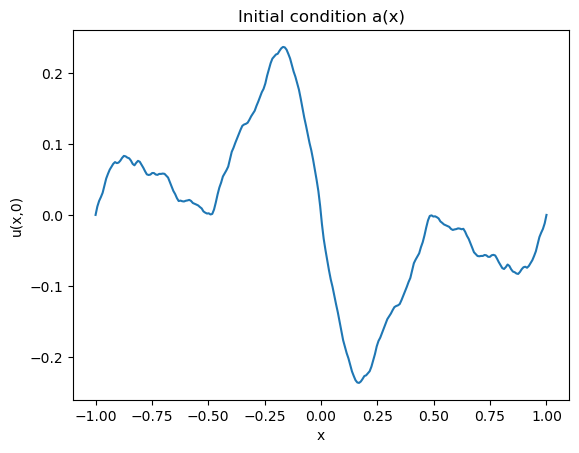

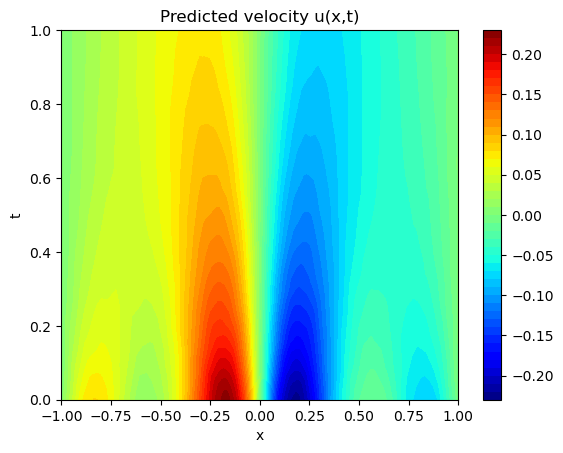

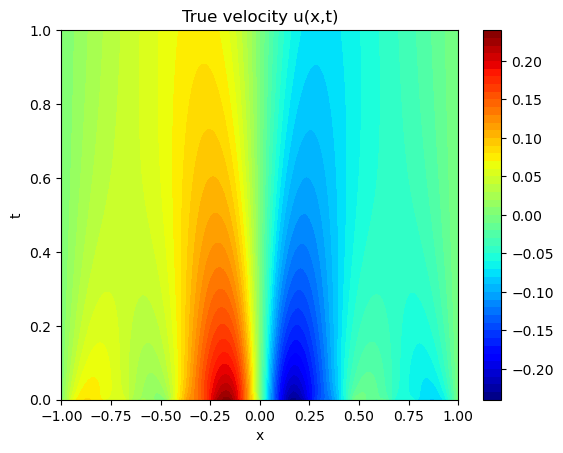

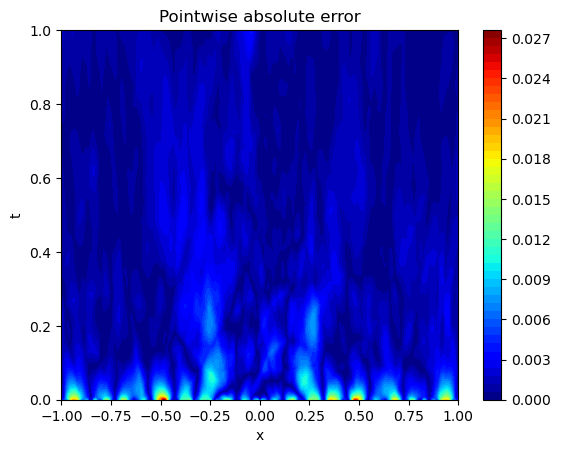

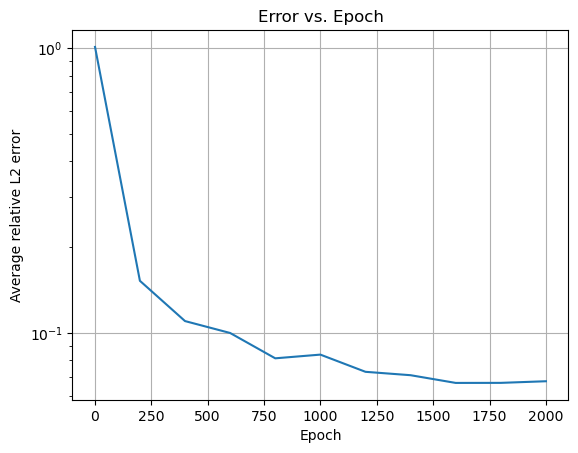

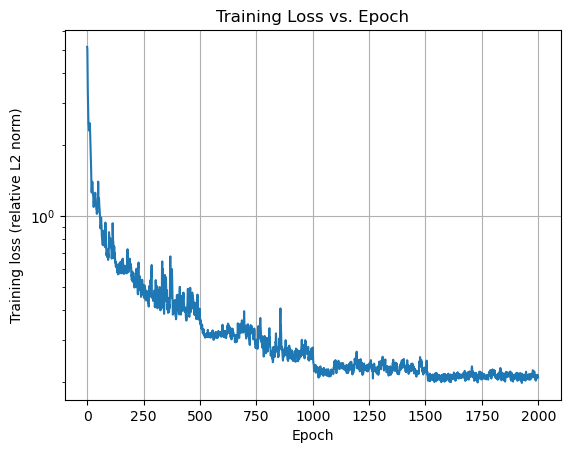

In [6]:
# First test instance plots
inx = 0
with torch.no_grad():
    a_plot = a_test[inx].cpu().numpy()
    u_true_plot = u_test[inx].cpu().numpy()
    tg, xg = torch.meshgrid(t_mesh, x_mesh, indexing='ij')
    xt_grid = torch.stack([tg.reshape(-1), xg.reshape(-1)], dim=1).unsqueeze(0)
    u_pred_plot = model(a_test[inx:inx+1], xt_grid).reshape(200, 256).cpu().numpy()
    abs_err = np.abs(u_pred_plot - u_true_plot)

    # 1. Initial condition a(x)
    plt.figure()
    plt.plot(x_mesh.cpu(), a_plot)
    plt.xlabel('x'); plt.ylabel('u(x,0)')
    plt.title('Initial condition a(x)')
    plt.savefig(os.path.join(output_dir, 'initial_condition.png'))
    plt.show()

    # 2. Predicted velocity field
    plt.figure()
    plt.contourf(x_mesh.cpu(), t_mesh.cpu(), u_pred_plot, levels=50, cmap='jet')
    plt.colorbar(); plt.xlabel('x'); plt.ylabel('t')
    plt.title('Predicted velocity u(x,t)')
    plt.savefig(os.path.join(output_dir, 'u_pred.png'))
    plt.show()

    # 3. Ground truth velocity field
    plt.figure()
    plt.contourf(x_mesh.cpu(), t_mesh.cpu(), u_true_plot, levels=50, cmap='jet')
    plt.colorbar(); plt.xlabel('x'); plt.ylabel('t')
    plt.title('True velocity u(x,t)')
    plt.savefig(os.path.join(output_dir, 'u_true.png'))
    plt.show()

    # 4. Pointwise absolute error
    plt.figure()
    plt.contourf(x_mesh.cpu(), t_mesh.cpu(), abs_err, levels=50, cmap='jet')
    plt.colorbar(); plt.xlabel('x'); plt.ylabel('t')
    plt.title('Pointwise absolute error')
    plt.savefig(os.path.join(output_dir, 'u_error.png'))
    plt.show()

# 5. Test error vs. epoch
recorded_epochs = [1] + list(range(200, epochs+1, 200))   # epoch 1, 200, 400, ...
recorded_epochs = recorded_epochs[:len(test_error_history)]
plt.figure()
plt.plot(recorded_epochs, test_error_history)
plt.xlabel('Epoch'); plt.ylabel('Average relative L2 error')
plt.yscale('log'); plt.grid(True)
plt.title('Error vs. Epoch')
plt.savefig(os.path.join(output_dir, 'error_vs_epoch.png'))
plt.show()

# 6. Training loss vs. epoch
plt.figure()
plt.plot(train_loss_history)
plt.xlabel('Epoch'); plt.ylabel('Training loss (relative L2 norm)')
plt.yscale('log'); plt.grid(True)
plt.title('Training Loss vs. Epoch')
plt.savefig(os.path.join(output_dir, 'train_loss.png'))
plt.show()

**Summary:** The model accurately captures the
nonlinear convection‑diffusion dynamics of Burgers’ equation, and inference
takes only milliseconds per initial condition.

Although unlabelled data were available, using only the 200 labelled samples
already provides strong performance, demonstrating the effectiveness of the
branch‑trunk architecture for operator learning.